# Models of Gene Expression: How to Choose One? 

This notebook shows how AutoReduce can be used to explore many possible models of gene expression and identify the most accurate model in different parameter regimes. The accuracy of a model depends on the selected output of interest, the parameter values, initial conditions and time interval. Using AutoReduce, many possible candidates can be explored and validated in different regions of parameter space. We use BioCRNpyler to build mechanistic models of gene expression as our starting point in this notebook.

But, first, let's set some plot settings for the notebook:

In [43]:
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings(
    "ignore",
    message="parameter file contains no unit column",
)

plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "figure.figsize": (7.5, 4.5),
        "font.size": 11,
    }
)

## Build CRN using BioCRNpyler

We use the BioCRNpyler component `DNAassembly` as the main Component of the system. We initialize this component in a mechanistic transcription-translation mixture. This mixture instantiates the resources needed for protein expression: RNAP, ribosomes, endonucleases. The transcription reaction produces the mRNA species and the translation of the mRNA to the final protein is included via complex formation. BioCRNpyler automatically generates the species, reactions, and parameters for this system from the high-level specification.

The species in this model include the RNA polymerase $P$, the gene-polymerase complex $C_1$, the mRNA transcript $T$, the free ribosomes $R$, the free endonucleases $E$, the transcript-ribosome complex $C_2$, the endonuclease-mRNA complex $C_3$, and the expressed protein $X$. Thus, we denote the state vector and output as

$$
x=\begin{bmatrix}P&C_1&T&E&R&C_2&C_3&X\end{bmatrix}^{\mathsf T},
\qquad y=X.
$$

Let's create this model using BioCRNpyler:


In [44]:
import biocrnpyler as bcp
from biocrnpyler.components import DNAassembly


TOTAL_DNA = 0.01
TOTAL_RNAP = 10
TOTAL_RIBOSOME = 20
TOTAL_RNAASE = 2.0

initial_conditions = {
    "dna_X": TOTAL_DNA,
    "protein_RNAP": TOTAL_RNAP,
    "protein_Ribo": TOTAL_RIBOSOME,
    "protein_RNase": TOTAL_RNAASE,
}

gene = DNAassembly(
    name="X",
    promoter="strong",
    rbs="strong",
    transcript="X",
    protein="X",
)
degradation = bcp.Dilution(
    mechanism_type="global_mechanism",
    filter_dict = {"X": True, "dna": False, "rna":False},
    default_on = False
)

txtl_extract = bcp.TxTlExtract(
    name="txtl",
    components=[gene],
    parameter_file="default_parameters.txt",
    initial_condition_dictionary=initial_conditions,
    global_mechanisms=[degradation]
)

crn = txtl_extract.compile_crn()
crn.write_sbml_file("models/biocrnpyler_gene_expression_resource.xml")

print(f"Species: {len(crn.species)}")
for species in crn.species:
    print(f"  {species}")

print(f"\nReactions: {len(crn.reactions)}")
for reaction in crn.reactions:
    print(f"  {reaction}")

Species: 9
  dna_X
  protein_RNAP
  rna_X
  complex_dna_X_protein_RNAP_
  protein_Ribo
  protein_X
  complex_protein_Ribo_rna_X_
  protein_RNase
  complex_protein_RNase_rna_X_

Reactions: 7
  dna[X]+protein[RNAP] <--> complex[dna[X]:protein[RNAP]]
  complex[dna[X]:protein[RNAP]] --> dna[X]+rna[X]+protein[RNAP]
  rna[X]+protein[Ribo] <--> complex[protein[Ribo]:rna[X]]
  complex[protein[Ribo]:rna[X]] --> rna[X]+protein[X]+protein[Ribo]
  protein[X] --> 
  rna[X]+protein[RNase] <--> complex[protein[RNase]:rna[X]]
  complex[protein[RNase]:rna[X]] --> protein[RNase]


c:\Users\ayush\anaconda3\envs\autoreduce\Lib\site-packages\biocrnpyler\mechanisms\global_mechanisms.py:204: UserWarning: species rna_X has multiple attributes (or material type) which conflict with global mechanism filter {repr(self)}. Using default value False.
  warn(
c:\Users\ayush\anaconda3\envs\autoreduce\Lib\site-packages\biocrnpyler\mechanisms\global_mechanisms.py:204: UserWarning: species complex_dna_X_protein_RNAP_ has multiple attributes (or material type) which conflict with global mechanism filter {repr(self)}. Using default value False.
  warn(
c:\Users\ayush\anaconda3\envs\autoreduce\Lib\site-packages\biocrnpyler\mechanisms\global_mechanisms.py:204: UserWarning: species complex_protein_Ribo_rna_X_ has multiple attributes (or material type) which conflict with global mechanism filter {repr(self)}. Using default value False.
  warn(
c:\Users\ayush\anaconda3\envs\autoreduce\Lib\site-packages\biocrnpyler\mechanisms\global_mechanisms.py:204: UserWarning: species dna_X has mult

## Load and rename the species

The SBML model can be loaded into AutoReduce using `load_sbml`. The SBML species names are descriptive but long. So, we use the `rename_species` argument in thie function that maps them to short symbols before the model is used for analysis.

In [45]:
from autoreduce import load_sbml
from sympy import symbols

G, P, T, C_1, R, X, C_2, E, C_3 = symbols("G P T C_1 R X C_2 E C_3")
G_tot, P_tot, R_tot, E_tot, kb = symbols("G_tot P_tot R_tot E_tot kb__")
species_rename = {
    "dna_X": "G",
    "protein_RNAP": "P",
    "rna_X": "T",
    "complex_dna_X_protein_RNAP_": "C_1",
    "protein_Ribo": "R",
    "protein_X": "X",
    "complex_protein_Ribo_rna_X_": "C_2",
    "complex_protein_RNase_rna_X_": "C_3",
    "protein_RNase": "E",
}

system = load_sbml(
    "models/biocrnpyler_gene_expression_resource.xml",
    outputs=["protein_X"],
    rename_species=species_rename,
)

species_to_index = {str(state): index for index, state in enumerate(system.x)}
for species_name, concentration in initial_conditions.items():
    state_name = species_rename[species_name]
    system.x_init[species_to_index[state_name]] = concentration

Your output 'protein_X' is now set using the system.C matrix!


In [46]:
print("States and initial conditions:")
for state, value in zip(system.x, system.x_init):
    print(f"  {state}: {value}")

States and initial conditions:
  G: 0.01
  P: 10
  T: 0.0
  C_1: 0.0
  R: 20
  X: 0.0
  C_2: 0.0
  E: 2.0
  C_3: 0.0


## Show the ODEs

In [47]:
from IPython.display import Math, display
from sympy import latex, simplify

rows = []
for state, rhs in zip(system.x, system.f):
    rows.append(rf"\dot{{{latex(state)}}} &= {latex(simplify(rhs))}")

display(Math(r"\begin{aligned}" + r"\\".join(rows) + r"\end{aligned}"))

<IPython.core.display.Math object>

## Simulate the full model

The selected output is protein $X$.

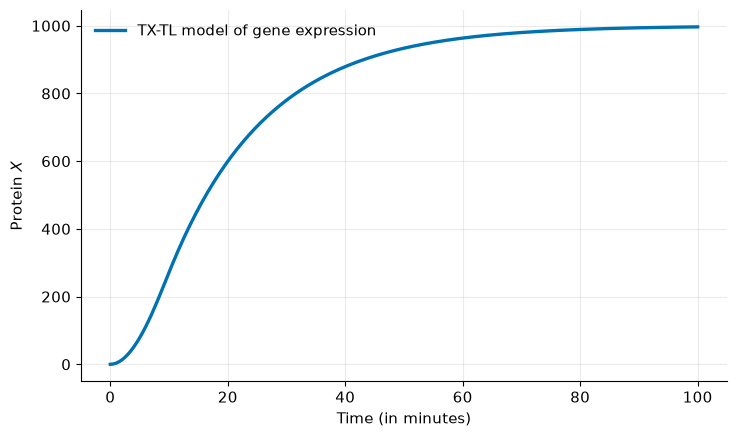

In [48]:
import numpy as np
from autoreduce import solve_ode

timepoints = np.linspace(0.0, 6000.0, 200)
solution = solve_ode(system, timepoints)
output = (system.C @ solution.T)[0]

fig, ax = plt.subplots()
ax.plot(timepoints/60, output, color="#0072B2",
        linewidth=2.4, label="TX-TL model of gene expression")
ax.set_xlabel("Time (in minutes)")
ax.set_ylabel("Protein $X$")
ax.legend(frameon=False)
plt.tight_layout()

## Compute output sensitivity

The sensitivity calculation uses the initial conditions imported from the SBML model. If the initial conditions are zero, then sensitivity computation can error out.

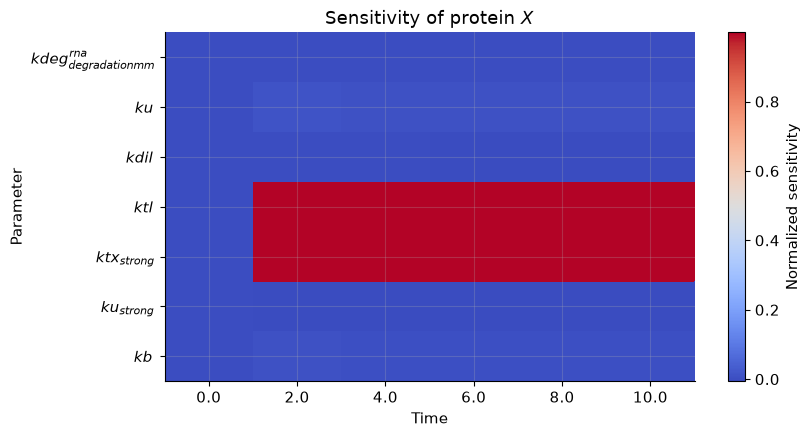

In [49]:
import numpy as np
from autoreduce import solve_sensitivity
from sympy import latex

sensitivity_timepoints = np.linspace(0.0, 10.0, 6)
state_sensitivities = solve_sensitivity(
    system,
    sensitivity_timepoints,
    normalize=True,
)
output_sensitivities = []
for sensitivities_at_time in state_sensitivities:
    output_sensitivities.append(np.asarray(system.C) @ sensitivities_at_time.T)
output_sensitivities = np.asarray(output_sensitivities)[:, 0, :]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
image = ax.imshow(
    output_sensitivities.T,
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
)
fig.colorbar(image, ax=ax, label="Normalized sensitivity")
ax.set_xticks(range(len(sensitivity_timepoints)))
ax.set_xticklabels([f"{time:.1f}" for time in sensitivity_timepoints])
ax.set_yticks(range(len(system.params)))
ax.set_yticklabels([f"${latex(param)}$" for param in system.params])
ax.set_xlabel("Time")
ax.set_ylabel("Parameter")
ax.set_title("Sensitivity of protein $X$")
plt.tight_layout()

## Apply conservation laws using AutoReduce

We use AutoReduce to find and apply the conservation laws in the system. 

We already know that it should find four conservation laws: one for the DNA, and three for the resources (RNAP, ribosomes, and endonucleases). The conservation laws are:
$$
G + C_1 = G_{\mathrm{tot}},\quad P+C_1=P_{\mathrm{tot}},\qquad R+C_2=R_{\mathrm{tot}},\quad E+C_3=E_{\mathrm{tot}}.
$$

Let's see if AutoReduce finds the same conservation laws. 

In [50]:
from autoreduce import find_conserved_sets

conserved_sets = find_conserved_sets(system, search_depth=2)

In [51]:
conserved_sets

[[G, C_1], [P, C_1], [R, C_2], [E, C_3]]

Perfect! Let's apply these laws!

In [52]:
from IPython.display import Math, display
from autoreduce import solve_conservation_laws
from sympy import latex, simplify

conserved_system = solve_conservation_laws(
    system,
    total_quantities={
        "G_tot": TOTAL_DNA,
        "P_tot": TOTAL_RNAP,
        "R_tot": TOTAL_RIBOSOME,
        "E_tot": TOTAL_RNAASE,
    },
    conserved_sets=conserved_sets,
    states_to_eliminate=[G, P, R, E],
)

print("States after conservation laws:")
for state in conserved_system.x:
    print(f"  {state}")

rows = []
for state, rhs in zip(conserved_system.x, conserved_system.f):
    rows.append(rf"\dot{{{latex(state)}}} &= {latex(simplify(rhs))}")

display(Math(r"\begin{aligned}" + r"\\".join(rows) + r"\end{aligned}"))

States after conservation laws:
  T
  C_1
  X
  C_2
  C_3


<IPython.core.display.Math object>

## Quasi-steady-state analysis

We can apply time-scale separation using AutoReduce. Here, we may assume that the complexes $C_1$, $C_2$, and $C_3$ are fast states, that is, their production and degradation rates are much faster than those of the retained transcript and protein. We use the `solve_timescale_separation` method in AutoReduce to solve their steady-state equations and substitute back to get the reduced model.

Successful solution obtained with states: [T, X]!


<IPython.core.display.Math object>

Reduced model MAE for protein X: 44.47


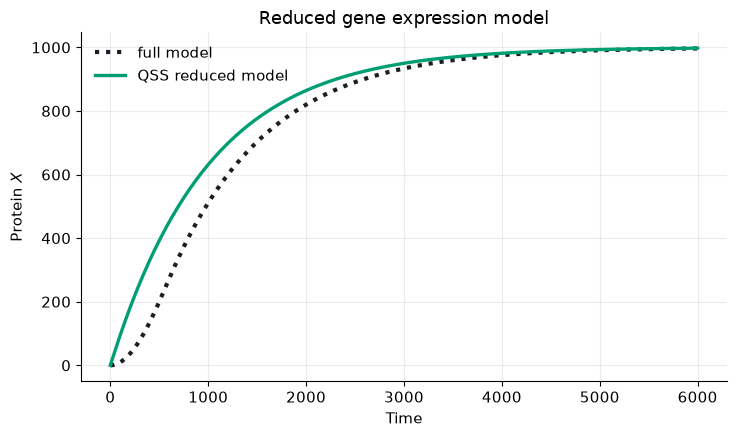

In [53]:
import numpy as np
from IPython.display import Math, display
from autoreduce import solve_ode, solve_timescale_separation
from sympy import latex, simplify

reduced_system, fast_subsystem = solve_timescale_separation(
    conserved_system,
    slow_states=[T, X],
    fast_states=[C_1, C_2, C_3],
    debug=False,
)

reduced_system.f = [simplify(rhs) for rhs in reduced_system.f]

rows = []
for state, rhs in zip(reduced_system.x, reduced_system.f):
    rows.append(rf"\dot{{{latex(state)}}} &= {latex(rhs)}")

display(Math(r"\begin{aligned}" + r"\\".join(rows) + r"\end{aligned}"))

reduced_solution = solve_ode(reduced_system, timepoints)
reduced_output = np.ravel(np.asarray(reduced_system.C) @ reduced_solution.T)
mae = np.mean(np.abs(output - reduced_output))
print(f"Reduced model MAE for protein X: {mae:.4g}")

fig, ax = plt.subplots()
ax.plot(timepoints, output, color="#1b1f23", linestyle=":", linewidth=3.0, label="full model")
ax.plot(timepoints, reduced_output, color="#009E73", linewidth=2.4, label="QSS reduced model")
ax.set_xlabel("Time")
ax.set_ylabel("Protein $X$")
ax.set_title("Reduced gene expression model")
ax.legend(frameon=False)
plt.tight_layout()

## Is mRNA-protein the only reduced model? Let's explore:

In AutoReduce, a method called `explore_all_QSS_models` is available to explore all possible reduced models of a system. Let's apply it to the gene expression model that we have built to see what we get.

In [54]:
conserved_system.f

[C_1*ktx_strong_ + C_2*ktl__ + C_2*ku_strong_ + C_3*ku__ - T*kb__*(-C_2 + R_tot) - T*kb__*(-C_3 + E_tot),
 -C_1*ktx_strong_ - C_1*ku_strong_ + kb__*(-C_1 + G_tot)*(-C_1 + P_tot),
 C_2*ktl__ - X*kdil__,
 -C_2*ktl__ - C_2*ku_strong_ + T*kb__*(-C_2 + R_tot),
 -C_3*kdeg__rna_degradation_mm - C_3*ku__ + T*kb__*(-C_3 + E_tot)]

In [55]:
from autoreduce import explore_all_QSS_models
all_reduced_models = explore_all_QSS_models(conserved_system,
                                            skip_numerical_computations=True,
                                            nstates_tol_min = 2)

Successful solution obtained with states: [T, X]!
Successful solution obtained with states: [C_1, X]!
Successful solution obtained with states: [X, C_2]!
Successful solution obtained with states: [X, C_3]!
Successful solution obtained with states: [T, C_1, X]!
Successful solution obtained with states: [T, X, C_2]!
Successful solution obtained with states: [T, X, C_3]!
Successful solution obtained with states: [C_1, X, C_2]!
Successful solution obtained with states: [C_1, X, C_3]!
Successful solution obtained with states: [X, C_2, C_3]!
Successful solution obtained with states: [T, C_1, X, C_2]!
Successful solution obtained with states: [T, C_1, X, C_3]!
Successful solution obtained with states: [T, X, C_2, C_3]!
Successful solution obtained with states: [C_1, X, C_2, C_3]!


In [56]:
print(f"Number of reduced models found: {len(all_reduced_models)}")

Number of reduced models found: 14


### Are any of these reduced models any good?

We explore some realistic parameter conditions below. 

## Limited RNAP resources

Under limited RNAP, we assume that the TOTAL_RNAP is lower than the default value. Under this condition, let's see how the different reduced models perform. Now that we have the shortlisted reduced models, we simulate and plot them under this parameter condition.

Currently, the total RNAP is set to:

In [57]:
TOTAL_RNAP

10

Under limited RNAP, we set

In [58]:
TOTAL_RNAP = 1.0

C:\Users\ayush\Box\Research\autoReduce_HPC\autoreduce\solvers\ode.py:64: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(


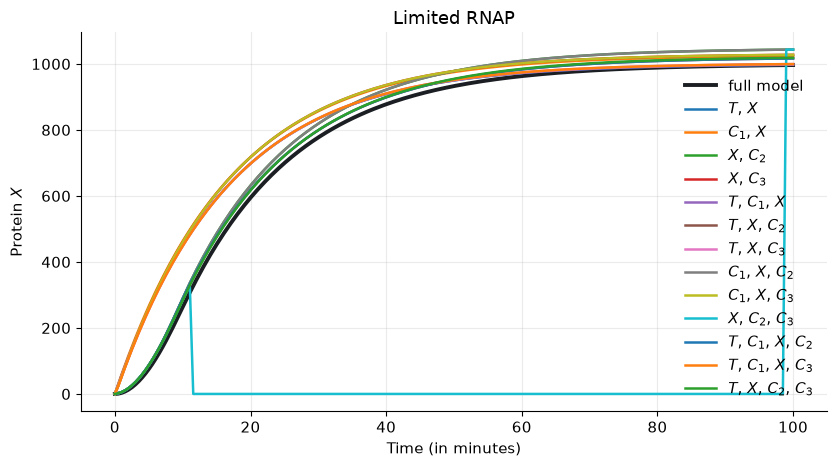

In [59]:
from autoreduce import get_error_metric
from sympy import latex

default_parameters = conserved_system.params_dict.copy()
limited_rnap_parameters = {
    **default_parameters,
    P_tot: TOTAL_RNAP,
}

conserved_system.set_param_dict(limited_rnap_parameters)

limited_rnap_solution = solve_ode(conserved_system, timepoints)
limited_rnap_output = (conserved_system.C @ limited_rnap_solution.T)[0]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    timepoints / 60,
    limited_rnap_output,
    color="#1b1f23",
    linewidth=2.8,
    label="full model",
)

limited_rnap_errors = []
limited_rnap_labels = []
for reduced_model in all_reduced_models:
    reduced_model.set_param_dict(limited_rnap_parameters)
    reduced_error = get_error_metric(
        conserved_system,
        reduced_model,
        timepoints_ode=timepoints,
    )
    reduced_label = ", ".join(rf"${latex(state)}$" for state in reduced_model.x)
    limited_rnap_errors.append(reduced_error)
    limited_rnap_labels.append(reduced_label)
    if reduced_error > 5000:
        continue
    reduced_solution = solve_ode(reduced_model, timepoints)
    reduced_output = (reduced_model.C @ reduced_solution.T)[0]
    ax.plot(
        timepoints / 60,
        reduced_output,
        linewidth=1.8,
        label=reduced_label,
    )

ax.set_xlabel("Time (in minutes)")
ax.set_ylabel("Protein $X$")
ax.set_title("Limited RNAP")
ax.legend(frameon=False)
plt.tight_layout()

## Unlimited resources

Another possibility is that the resources are abundant. In this case, we can set the `TOTAL_RNAP`, `TOTAL_RIBOSOMES`, and `TOTAL_ENDONUCLEASES` to a high value. 

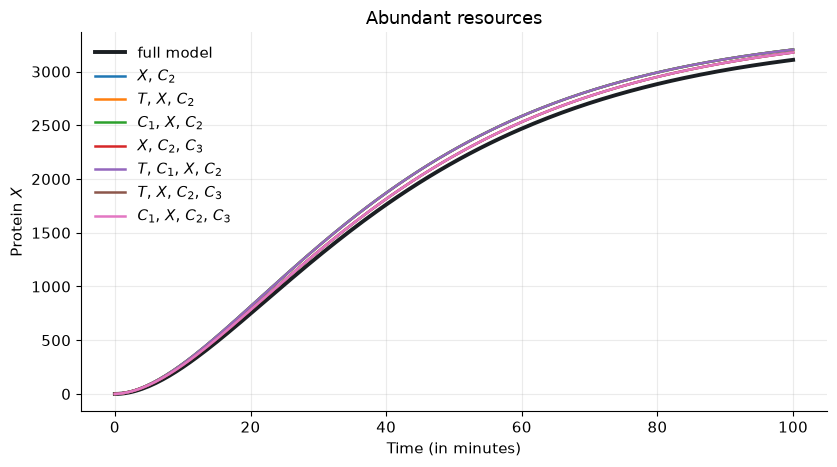

In [60]:
from autoreduce import get_error_metric
from sympy import latex

TOTAL_RNAP = 1000.0
TOTAL_RIBOSOME = 1000.0
TOTAL_RNAASE = 1000.0

unlimited_resource_parameters = {
    **default_parameters,
    P_tot: TOTAL_RNAP,
    R_tot: TOTAL_RIBOSOME,
    E_tot: TOTAL_RNAASE,
}

conserved_system.set_param_dict(unlimited_resource_parameters)

unlimited_solution = solve_ode(conserved_system, timepoints)
unlimited_output = (conserved_system.C @ unlimited_solution.T)[0]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    timepoints / 60,
    unlimited_output,
    color="#1b1f23",
    linewidth=2.8,
    label="full model",
)

unlimited_resource_errors = []
unlimited_resource_labels = []
for reduced_model in all_reduced_models:
    reduced_model.set_param_dict(unlimited_resource_parameters)
    reduced_error = get_error_metric(
        conserved_system,
        reduced_model,
        timepoints_ode=timepoints,
    )
    reduced_label = ", ".join(rf"${latex(state)}$" for state in reduced_model.x)
    unlimited_resource_errors.append(reduced_error)
    unlimited_resource_labels.append(reduced_label)
    if reduced_error > 5000:
        continue
    reduced_solution = solve_ode(reduced_model, timepoints)
    reduced_output = (reduced_model.C @ reduced_solution.T)[0]
    ax.plot(
        timepoints / 60,
        reduced_output,
        linewidth=1.8,
        label=reduced_label,
    )

ax.set_xlabel("Time (in minutes)")
ax.set_ylabel("Protein $X$")
ax.set_title("Abundant resources")
ax.legend(frameon=False)
plt.tight_layout()

## Weak ribosome binding strength

Under the condition that the ribosome binds very weakly to the mRNA, we have that $k_{b}$ is very small. In this case, we set $k_{b}=1$ instead of the original value of 100.

In [61]:
conserved_system.params_dict

{kb__: 100.0,
 ku_strong_: 0.5,
 ktx_strong_: 3.926187672,
 ktl__: 0.05,
 kdil__: 0.001,
 ku__: 10.0,
 kdeg__rna_degradation_mm: 0.01,
 G_tot: 0.01,
 P_tot: 1000.0,
 R_tot: 1000.0,
 E_tot: 1000.0}

The error is NaN, something wrong...continuing.


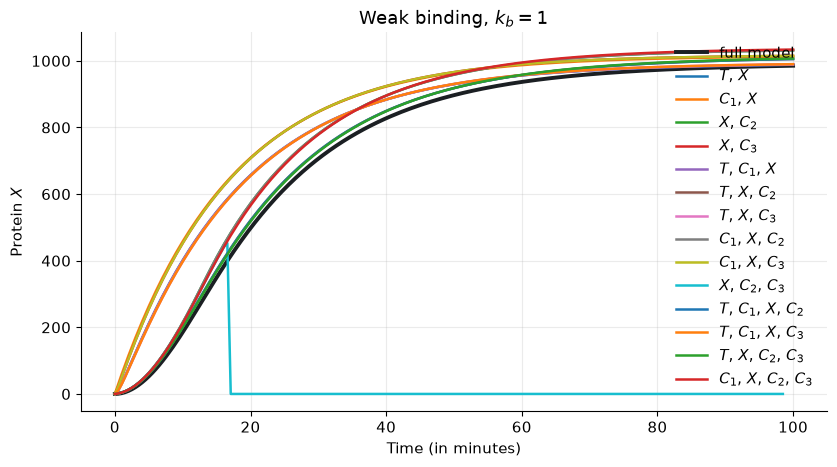

In [62]:
from autoreduce import get_error_metric
from sympy import latex

TOTAL_RNAP = initial_conditions["protein_RNAP"]
TOTAL_RIBOSOME = initial_conditions["protein_Ribo"]
TOTAL_RNAASE = initial_conditions["protein_RNase"]

weak_binding_parameters = {
    **default_parameters,
    P_tot: TOTAL_RNAP,
    R_tot: TOTAL_RIBOSOME,
    E_tot: TOTAL_RNAASE,
    kb: 1.0,
}

conserved_system.set_param_dict(weak_binding_parameters)

weak_binding_solution = solve_ode(conserved_system, timepoints)
weak_binding_output = (conserved_system.C @ weak_binding_solution.T)[0]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    timepoints / 60,
    weak_binding_output,
    color="#1b1f23",
    linewidth=2.8,
    label="full model",
)

weak_binding_errors = []
weak_binding_labels = []
for reduced_model in all_reduced_models:
    reduced_model.set_param_dict(weak_binding_parameters)
    reduced_error = get_error_metric(
        conserved_system,
        reduced_model,
        timepoints_ode=timepoints,
    )
    reduced_label = ", ".join(rf"${latex(state)}$" for state in reduced_model.x)
    weak_binding_errors.append(reduced_error)
    weak_binding_labels.append(reduced_label)
    if reduced_error > 5000:
        continue
    reduced_solution = solve_ode(reduced_model, timepoints)
    reduced_output = (reduced_model.C @ reduced_solution.T)[0]
    ax.plot(
        timepoints / 60,
        reduced_output,
        linewidth=1.8,
        label=reduced_label,
    )

ax.set_xlabel("Time (in minutes)")
ax.set_ylabel("Protein $X$")
ax.set_title("Weak binding, $k_b = 1$")
ax.legend(frameon=False)
plt.tight_layout()

## Accuracy of the reduced models

Here, we compare the accuracy of the reduced models in representing the desired output: `protein_X`. This can be done in AutoReduce using the `get_error_metric` method. This metric is based on the difference between the output of the full model and the reduced model. 

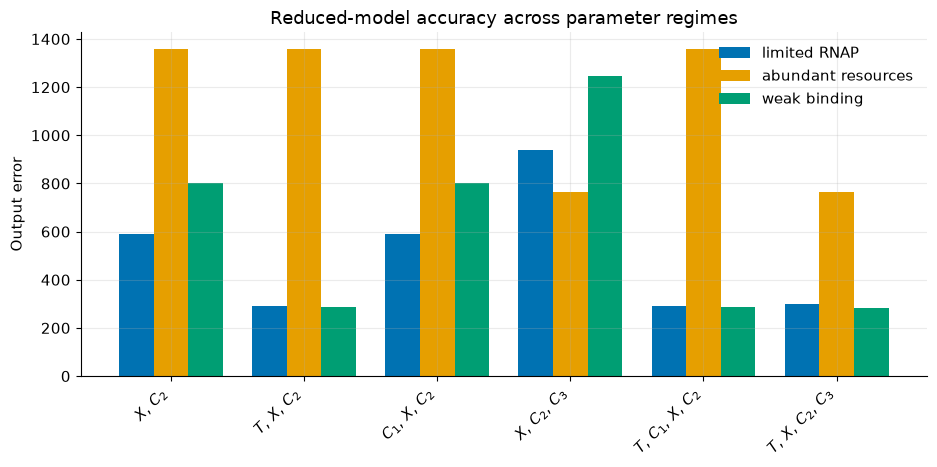

In [63]:
from autoreduce import get_error_metric
from sympy import latex

accuracy_conditions = [
    ("limited RNAP", limited_rnap_parameters),
    ("abundant resources", unlimited_resource_parameters),
    ("weak binding", weak_binding_parameters),
]
accuracy_labels = [
    ", ".join(rf"${latex(state)}$" for state in reduced_model.x)
    for reduced_model in all_reduced_models
]
accuracy_values = []

for condition_name, condition_parameters in accuracy_conditions:
    condition_errors = []
    conserved_system.set_param_dict(condition_parameters)
    for reduced_model in all_reduced_models:
        reduced_model.set_param_dict(condition_parameters)
        error = get_error_metric(
            conserved_system,
            reduced_model,
            timepoints_ode=timepoints,
        )
        condition_errors.append(error)
    accuracy_values.append(condition_errors)

accuracy_values = np.asarray(accuracy_values)
models_to_plot = np.all(accuracy_values <= 5000, axis=0)
accuracy_values = accuracy_values[:, models_to_plot]
accuracy_labels = [
    label for label, keep_model in zip(accuracy_labels, models_to_plot)
    if keep_model
]
model_positions = np.arange(len(accuracy_labels))
bar_width = 0.26

fig, ax = plt.subplots(figsize=(9.5, 4.8))
colors = ["#0072B2", "#E69F00", "#009E73"]
for condition_index, (condition_name, _) in enumerate(accuracy_conditions):
    ax.bar(
        model_positions + bar_width * (condition_index - 1),
        accuracy_values[condition_index],
        width=bar_width,
        color=colors[condition_index],
        label=condition_name,
    )

ax.set_xticks(model_positions)
ax.set_xticklabels(accuracy_labels, rotation=45, ha="right")
ax.set_ylabel("Output error")
ax.set_title("Reduced-model accuracy across parameter regimes")
ax.legend(frameon=False)
plt.tight_layout()

## Robustness to parametric uncertainties among the possible models

Among all possible models, is there a clear winner in terms of robustness to parametric uncertainties? With AutoReduce, we can compute a robustness metric associated with each reduced model using `get_robustness_metric`. This metric is based on the sensitivity of the output to the parameters. A lower sensitivity indicates that the model is more robust to parametric uncertainties. Let's compute this metric for all the reduced models and see which one is the most robust. 

C:\Users\ayush\Box\Research\autoReduce_HPC\autoreduce\solvers\ode.py:64: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(


C:\Users\ayush\Box\Research\autoReduce_HPC\autoreduce\solvers\ssm.py:239: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(sens_func_ode, S0, timepoints, tfirst=True)


SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete
SSM 

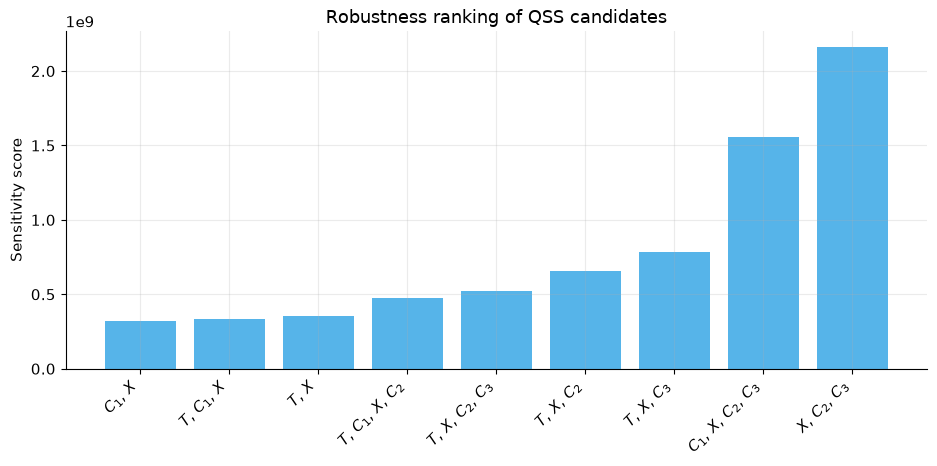

In [64]:
from autoreduce import get_robustness_metric
from sympy import latex

robustness_timepoints_ode = np.linspace(0.0, 6000.0, 120)
robustness_timepoints_ssm = np.linspace(0.0, 6000.0, 8)

conserved_system.set_param_dict(default_parameters)

robustness_labels = []
sensitivity_scores = []
robustness_scores = []

for reduced_model in all_reduced_models:
    reduced_model.set_param_dict(default_parameters)
    sensitivities, robustness = get_robustness_metric(
        conserved_system,
        reduced_model,
        timepoints_ode=robustness_timepoints_ode,
        timepoints_ssm=robustness_timepoints_ssm,
    )
    robustness_labels.append(", ".join(rf"${latex(state)}$" for state in reduced_model.x))
    sensitivity_scores.append(np.linalg.norm(sensitivities))
    robustness_scores.append(robustness)

models_to_plot = [
    index for index, score in enumerate(sensitivity_scores)
    if score <= 1e10
]
model_order = sorted(models_to_plot, key=lambda index: sensitivity_scores[index])
ordered_labels = [robustness_labels[index] for index in model_order]
ordered_sensitivity_scores = [sensitivity_scores[index] for index in model_order]
ordered_robustness_scores = [robustness_scores[index] for index in model_order]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar(
    np.arange(len(ordered_labels)),
    ordered_sensitivity_scores,
    color="#56B4E9",
)
ax.set_xticks(np.arange(len(ordered_labels)))
ax.set_xticklabels(ordered_labels, rotation=45, ha="right")
ax.set_ylabel("Sensitivity score")
ax.set_title("Robustness ranking of QSS candidates")
plt.tight_layout()

print(f"Most robust reduced model: {ordered_labels[0]}")
print(f"Sensitivity score: {ordered_sensitivity_scores[0]:.4g}")
print(f"Robustness metric: {ordered_robustness_scores[0]:.4g}")

In [65]:
# end